# 03 · Explore demand and electricity prices

Solve independent investment cases and plot where a gas turbine becomes economical. This notebook repeats its input definitions so it can run alone.

Use Python 3.14.2 or newer. In a terminal, run `python -m pip install "OpenUtility[notebook]>=0.1.2"`, then `python -m jupyterlab`. Select that environment's Python kernel and choose **Restart Kernel and Run All Cells**. No repository checkout, external files, credentials, or commercial solver is needed; HiGHS comes with OpenUtility. All data and prices below are synthetic, in arbitrary currency units (CU).

In [1]:
from importlib.metadata import version
import math
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import OpenUtility as ou
from IPython.display import display

print(f"OpenUtility {version('OpenUtility')}")
plt.rcParams.update(
    {"figure.figsize": (7, 4), "axes.spines.top": False, "axes.spines.right": False}
)
solve = ou.pyomo_utility_system_solver("appsi_highs")

OpenUtility 0.1.2


## Build each scenario independently

Use the same 40%-efficient, 140 kW turbine as notebook 02: 0.04 CU/kWh fuel, 12,000 CU/year annualized capital, and 4,000 operating hours. Power slope and fuel heating value are kJ/kg, fuel flow is kg/s. Each scenario permits a fresh investment decision; this is not a dispatch study with one fixed installed fleet.

In [2]:
# The current schema requires a steam level, even for electricity/HPR examples.
# This zero-duty placeholder contributes no heat, steam, or cost.
level = ou.SteamLevelCandidate(
    name="MP_100",
    steam_main="MP",
    temperature=100.0,
    source_heat_available=0.0,
    sink_heat_demand=0.0,
    generation_enthalpy_delta=1.0,
    use_enthalpy_delta=1.0,
)


def electricity_case(demand=100.0, tariff=0.20):
    return ou.UtilitySystemModelData(
        steam_mains=("MP",),
        steam_levels=(level,),
        power_demand=demand,
        operating_hours=4000.0,
        grid_import_limit=200.0,
        grid_export_limit=0.0,
        electricity_cost=ou.ElectricityCost(import_unit_cost=tariff),
        gas_turbines=(
            ou.GasTurbineCandidate(
                name="GT",
                fuel_lhv=50000.0,
                power_slope=20000.0,
                power_intercept=0.0,
                min_fuel_flow=0.0,
                max_fuel_flow=0.007,
                minimum_load_fraction=0.0,
            ),
        ),
        fuel_costs=(
            ou.FuelCost(
                name="gas",
                equipment_type="gas_turbine",
                equipment_name="GT",
                unit_cost=0.04,
            ),
        ),
        equipment_costs=(
            ou.EquipmentCost(
                name="GT investment",
                equipment_type="gas_turbine",
                equipment_name="GT",
                annualization_factor=0.1,
                installation_factor=1.0,
                variable_capital_cost=0.0,
                fixed_capital_cost=120000.0,
            ),
        ),
    )


rows = []
for demand in (40.0, 100.0):
    for tariff in (0.08, 0.12, 0.16, 0.20):
        model = ou.build_utility_system_model(electricity_case(demand, tariff))
        status = solve(model)
        assert status.termination_condition == "optimal", status
        cost = pyo.value(model.total_annualized_cost)
        expected = min(demand * tariff * 4000, demand * 0.10 * 4000 + 12000)
        assert math.isclose(cost, expected, abs_tol=1e-5)
        rows.append(
            {
                "Demand (kW)": demand,
                "Tariff (CU/kWh)": tariff,
                "Annual cost (CU/year)": cost,
                "Build GT": pyo.value(model.gas_turbine_selected["GT"]) > 0.5,
                "GT power (kW)": pyo.value(model.gas_turbine_power_generation["GT"]),
                "Fuel input (kW)": pyo.value(model.gas_turbine_fuel_flow["GT"]) * 50000,
            }
        )
scenarios = pd.DataFrame(rows)
display(scenarios)

,Demand (kW),Tariff (CU/kWh),Annual cost (CU/year),Build GT,GT power (kW),Fuel input (kW)
0,40.0,0.08,12800.0,False,0.0,0.0
1,40.0,0.12,19200.0,False,0.0,0.0
2,40.0,0.16,25600.0,False,0.0,0.0
3,40.0,0.20,28000.0,True,40.0,100.0
4,100.0,0.08,32000.0,False,0.0,0.0
5,100.0,0.12,48000.0,False,0.0,0.0
6,100.0,0.16,52000.0,True,100.0,250.0
7,100.0,0.20,52000.0,True,100.0,250.0


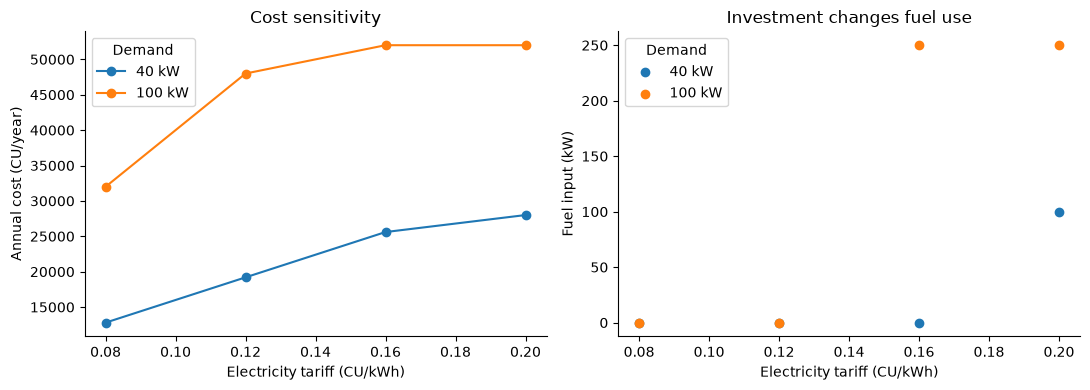

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for demand, group in scenarios.groupby("Demand (kW)"):
    axes[0].plot(
        group["Tariff (CU/kWh)"],
        group["Annual cost (CU/year)"],
        marker="o",
        label=f"{demand:g} kW",
    )
    axes[1].scatter(
        group["Tariff (CU/kWh)"],
        group["Fuel input (kW)"],
        marker="o",
        label=f"{demand:g} kW",
    )
axes[0].set(ylabel="Annual cost (CU/year)", title="Cost sensitivity")
axes[1].set(ylabel="Fuel input (kW)", title="Investment changes fuel use")
for ax in axes:
    ax.set_xlabel("Electricity tariff (CU/kWh)")
    ax.legend(title="Demand")
plt.tight_layout()
plt.show()

## Interpret the transition

The break-even tariff is `0.10 + 12000 / (demand × 4000)` CU/kWh: **0.175** at 40 kW and **0.130** at 100 kW. Higher utilization spreads the fixed annual cost over more output. At exact break-even, either investment choice may be optimal. Try changing operating hours or fuel price and update the analytical check accordingly.